## Evaluación de solicitud de crédito bancaria


## Percepción: monto solicitado e ingreso mensual del cliente.

Acciones: aprobar, revisar o rechazar la solicitud.

Entorno: sistema de evaluación de créditos de una entidad financiera.

Medida de desempeño: porcentaje de decisiones correctas y reducción del riesgo de otorgar créditos a clientes con baja capacidad de pago.


Objetivo: tomar una decisión rápida y coherente sobre la solicitud de crédito.

## Justificación de las reglas

- Si no tiene historial moroso y la relación es menor o igual a 0.30, se aprueba.
- Si no tiene historial moroso y la relación es mayor a 0.30 y menor o igual a 0.50, se aprueba con condiciones.
- Si tiene historial moroso y la relación es menor o igual a 0.30, se aprueba con condiciones.
- Si tiene historial moroso y la relación es mayor a 0.30, se rechaza.
- Si la relación es mayor a 0.50, se rechaza.

## Implementación de código

In [7]:
def agente_credito(ingreso_mensual, monto_solicitado, tiene_historial_moroso):
    relacion = monto_solicitado / ingreso_mensual

    if relacion <= 0.30 and not tiene_historial_moroso:
        return "aprobar", "relacion monto/ingreso baja y no tiene historial moroso"

    elif relacion <= 0.50 and not tiene_historial_moroso:
        return "aprobar con condiciones", "relacion monto/ingreso moderada y no tiene historial moroso"

    elif relacion <= 0.30 and tiene_historial_moroso:
        return "aprobar con condiciones", "relacion monto/ingreso baja pero tiene historial moroso"

    else:
        return "rechazar", "relacion monto/ingreso alta o existe historial moroso"


  ## Simulación y pruebas

In [8]:
casos = [
    (4000, 1000, False),
    (4000, 1200, False),
    (4000, 2000, False),
    (4000, 2000, True),
    (4000, 1000, True),
    (4000, 2001, True)
]

for ingreso, monto, historial in casos:
    accion, motivo = agente_credito(ingreso, monto, historial)

    relacion = monto / ingreso

    print(f"Ingreso: S/ {ingreso}")
    print(f"Monto solicitado: S/ {monto}")
    print(f"Relación: {relacion:.2f}")
    print(f"Historial moroso: {historial}")
    print(f"Acción: {accion}")
    print(f"Motivo: {motivo}")
    print("-" * 50)

Ingreso: S/ 4000
Monto solicitado: S/ 1000
Relación: 0.25
Historial moroso: False
Acción: aprobar
Motivo: relacion monto/ingreso baja y no tiene historial moroso
--------------------------------------------------
Ingreso: S/ 4000
Monto solicitado: S/ 1200
Relación: 0.30
Historial moroso: False
Acción: aprobar
Motivo: relacion monto/ingreso baja y no tiene historial moroso
--------------------------------------------------
Ingreso: S/ 4000
Monto solicitado: S/ 2000
Relación: 0.50
Historial moroso: False
Acción: aprobar con condiciones
Motivo: relacion monto/ingreso moderada y no tiene historial moroso
--------------------------------------------------
Ingreso: S/ 4000
Monto solicitado: S/ 2000
Relación: 0.50
Historial moroso: True
Acción: rechazar
Motivo: relacion monto/ingreso alta o existe historial moroso
--------------------------------------------------
Ingreso: S/ 4000
Monto solicitado: S/ 1000
Relación: 0.25
Historial moroso: True
Acción: aprobar con condiciones
Motivo: relacion 

## Gráfica de clasificación de solicitudes

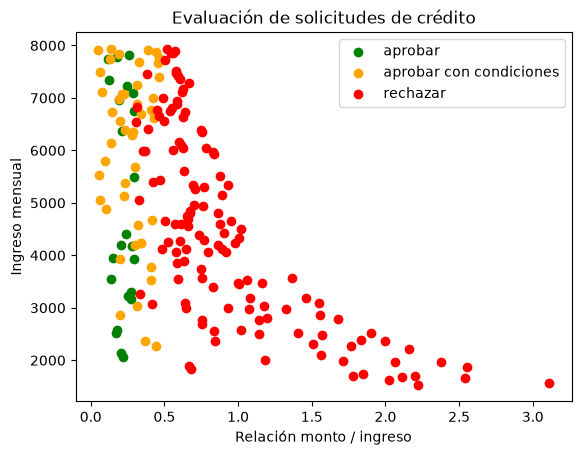

In [9]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

ingresos = np.random.randint(1500, 8000, 200)
montos = np.random.randint(300, 5000, 200)
historiales = np.random.choice([False, True], 200)

relaciones = []
decisiones = []

for ingreso, monto, historial in zip(ingresos, montos, historiales):
    relacion = monto / ingreso
    accion, motivo = agente_credito(ingreso, monto, historial)

    relaciones.append(relacion)
    decisiones.append(accion)

colores = {
    "aprobar": "green",
    "aprobar con condiciones": "orange",
    "rechazar": "red"
}

for accion in colores:
    x = [relaciones[i] for i in range(200) if decisiones[i] == accion]
    y = [ingresos[i] for i in range(200) if decisiones[i] == accion]

    plt.scatter(x, y, label=accion, color=colores[accion])

plt.xlabel("Relación monto / ingreso")
plt.ylabel("Ingreso mensual")
plt.title("Evaluación de solicitudes de crédito")
plt.legend()
plt.show()